# NASA battery Dataset EDA

For the pruposes of this project, I will be using the NASA battery dataset, which contains data from 4 different batteries. Each battery has been cycled until failure, and the dataset includes various measurements such as voltage, current, temperature, and capacity over time.

## Data Structure

Originally the dataset is in `.mat` format, converted to `.csv` for easier handling.
Each discharge cycle is one CSV file. Only discharge cycles are used — charge and impedance cycles are excluded.

Columns:
- `time_s`: Seconds elapsed since discharge start. Irregular spacing (~10Hz but not exact).
- `voltage_V`: Battery terminal voltage (V). Starts ~4.2V, falls to cutoff ~2.7V. Most informative signal for SOC.
- `current_A`: Output current (A). Negative during discharge (~-2A constant). Negative = energy leaving battery.
- `temperature_C`: Battery surface temperature (°C). Rises during discharge due to internal resistance heating.
- `capacity_Ah`: Total charge delivered this cycle (Ah). **Scalar repeated per row.** Decreases across cycles as the battery ages. Used as Coulomb counting denominator.
- `soc`: Ground truth State of Charge ∈ [0, 1], computed via Coulomb counting using per-cycle `capacity_Ah`.
- `cycle_index`: Original cycle number in the `.mat` file — proxy for battery age.
- `battery`: Battery identifier e.g. `B0005`.

The dataset contains 4 batteries (B0005, B0006, B0007, B0018). For initial training and 
exploration, only `B0005` is used - it is the most commonly referenced battery in the 
literature, has the most cycles (~168), and provides a clean room-temperature constant-current 
discharge profile. B0006 is reserved as a held-out test for cross-battery generalization, 
which is a natural extension of this work.

# Visualization

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

### Load in data

In [2]:
DATA_DIR = "data/processed/B0005/"
# we need to load all the cycle csvs and concatenate them into a single dataframe
cycle_dfs = []
for filename in sorted(os.listdir(DATA_DIR)):
    if filename.endswith(".csv"):
        df = pd.read_csv(os.path.join(DATA_DIR, filename))
        cycle_dfs.append(df)

print(f"{len(cycle_dfs)} Discharge Cycles")
print(f"")

168 Discharge Cycles



## Capacity fade across cycles

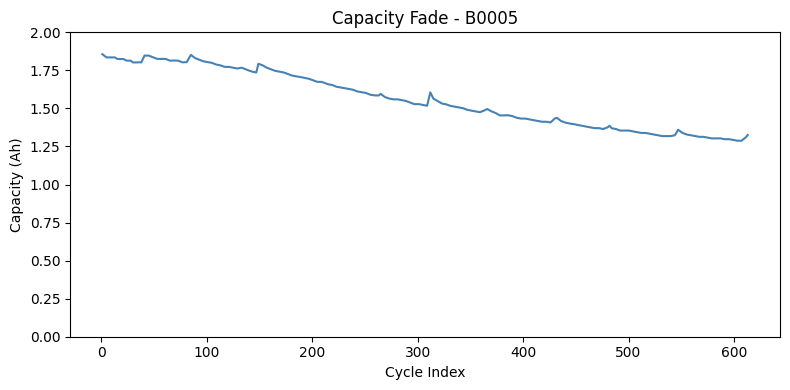

In [3]:
# first we need to get every cycles' capacities and number
capacities = []
cycle_numbers = []


for df in cycle_dfs:
    cycle_capacity = df["capacity_Ah"].iloc[0]
    cycle_number = df["cycle_index"].iloc[0]
    capacities.append(cycle_capacity)
    cycle_numbers.append(cycle_number)
plt.figure(figsize=(8, 4))
plt.plot(cycle_numbers, capacities, color="steelblue", linewidth=1.5)
plt.xlabel("Cycle Index")
plt.ylabel("Capacity (Ah)")
plt.title("Capacity Fade - B0005")
plt.ylim(0, 2)
plt.tight_layout()
plt.savefig("figures/capacity_fade.png", dpi=150)
plt.show()


Exactly what we expect, the battery's capacity degrades over time as it undegoes more charge-discharge cycles. The slight jumps in capacity are probably due to measurement noise or resting periods between cycles, which can allow the battery to recover some capacity temporarily. Overall, this plot confirms that the battery is aging as expected, which is important for training a model to predict SOC across the battery's lifecycle.

## Voltage discharge curves overlaid

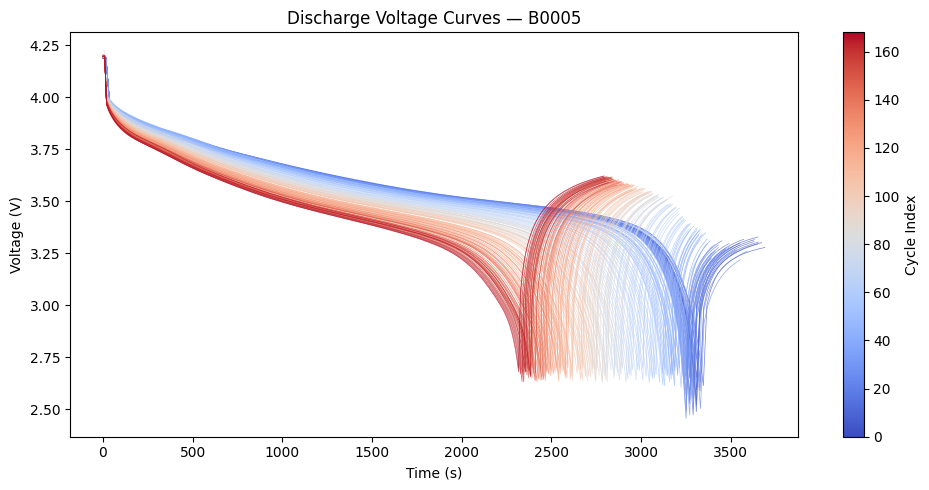

In [4]:

import matplotlib.cm as cm # we want color for this next part
fig, ax = plt.subplots(figsize=(10, 5))

cmap = cm.coolwarm # blue to red, cmap's don't repeat either
num_cycles = len(cycle_dfs) 

for i, df in enumerate(cycle_dfs):
    color = cmap(i / num_cycles)
    ax.plot(df["time_s"], df["voltage_V"], color=color, linewidth=0.5, alpha=0.7)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")
ax.set_title("Discharge Voltage Curves — B0005")

# colorbar to show cycle progression
sm = cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, num_cycles))
fig.colorbar(sm, ax=ax, label="Cycle Index")

plt.tight_layout()
plt.savefig("figures/voltage_curves.png", dpi=150)
plt.show()



This is pretty nice looking, but starting around (t = ~2350) there's these bizzare upward curves. Volatge shouldn't be increasing over time in a cycle - that makes no sense for a discharge cycle. Let's find out which cycles have a higher voltage at cycle's end than at cycle start.

In [10]:
for i, df in enumerate(cycle_dfs):
    first_voltage = df["voltage_V"].iloc[0]
    last_voltage = df["voltage_V"].iloc[-1]
    if last_voltage > first_voltage:
        print(f"Cycle {i}: first={first_voltage:.3f}V, last={last_voltage:.3f}V")

Well, that means there are no cycles like that, but our graph clearly shows otherwise. Maybe in some cycles, time is reversed? Let's check

In [11]:
for i, df in enumerate(cycle_dfs):
    first_time = df["time_s"].iloc[0]
    last_time = df["time_s"].iloc[-1]
    if first_time > last_time:
        print(f"Cycle {i}: first={first_time:.3f}s, last={last_time:.3f}s")  

None yet again. Hmm. Let's see if its present in only a few subgroups of cycles.

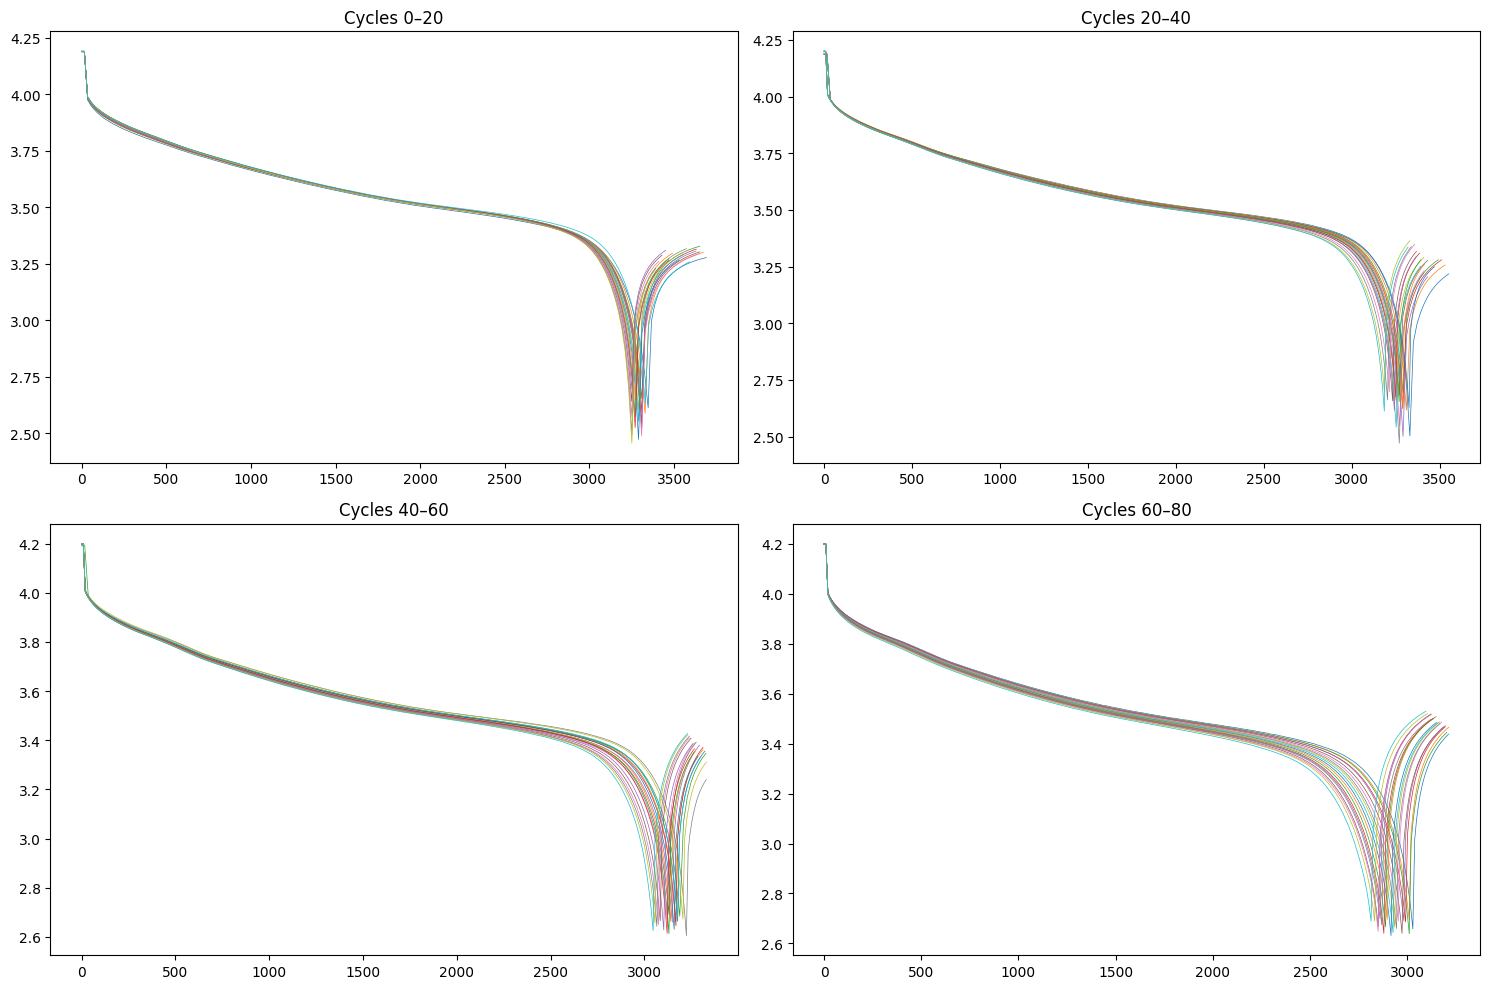

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

chunk_size = 20
for ax_idx, start in enumerate(range(0, 80, chunk_size)):
    chunk = cycle_dfs[start:start + chunk_size]
    for df in chunk:
        axes[ax_idx].plot(df["time_s"], df["voltage_V"], linewidth=0.5)
    axes[ax_idx].set_title(f"Cycles {start}–{start + chunk_size}")

plt.tight_layout()
plt.show()

It is - this suggests that its on purpose. I looked it up, and this is probably the relaxation effect after disconnection. To verify, I printed the last 5 observations of the first cycle.

In [22]:
# print out a first observation for comparison
print(cycle_dfs[0].iloc[2])
print(cycle_dfs[0].tail(5))

time_s              35.703
voltage_V         3.974871
current_A        -2.012528
temperature_C    24.389085
soc               0.994298
capacity_Ah       1.856487
cycle_index              1
battery              B0005
Name: 2, dtype: object
       time_s  voltage_V  current_A  temperature_C  soc  capacity_Ah  \
192  3608.594   3.258705  -0.001513      35.296711  0.0     1.856487   
193  3628.953   3.264121  -0.001532      35.021738  0.0     1.856487   
194  3649.375   3.269030  -0.000406      34.754871  0.0     1.856487   
195  3669.875   3.273207  -0.000388      34.490078  0.0     1.856487   
196  3690.234   3.277170  -0.006528      34.230853  0.0     1.856487   

     cycle_index battery  
192            1   B0005  
193            1   B0005  
194            1   B0005  
195            1   B0005  
196            1   B0005  


Voltage is increasing over time while current is still negative, but given how close the current is to 0, we can assume that its' just instrument noise. Let's redo the plot so its a nicer figure, but ignoring any observations with currents greater than -1.0 amps. In fact, let's remember to remove the relaxation phase in all cycles when we preprocess. For our model, we don't care about 